## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## Load dataset

In [2]:
df = pd.read_csv("../data/simulated_server_metric_with_predictive_anomalies.csv", parse_dates=['timestamp'])
df.head()

,timestamp,server_id,server_type,cpu_percent,memory_percent,disk_io,is_anomaly,is_predictive_anomaly,anomaly_type
0,2025-01-01 00:00:00,web_1,web,24.585207,33.194309,51.865857,0,0,normal
1,2025-01-01 00:05:00,web_1,web,26.946724,37.129782,48.890155,0,0,normal
2,2025-01-01 00:10:00,web_1,web,29.583721,35.496424,45.627445,0,0,normal
3,2025-01-01 00:15:00,web_1,web,24.330454,30.116072,50.508945,0,0,normal
4,2025-01-01 00:20:00,web_1,web,24.356086,32.283149,47.617581,0,0,normal


In [3]:
print(df.shape)
print(df['is_anomaly'].value_counts())
print(df['is_predictive_anomaly'].value_counts())

(181440, 9)
is_anomaly
0    181271
1       169
Name: count, dtype: int64
is_predictive_anomaly
0    181371
1        69
Name: count, dtype: int64


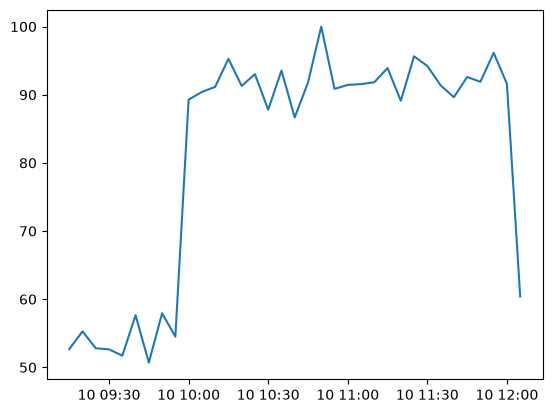

In [8]:
# Specifc anomaly within web_1 between 2025-01-10 10:00 - 2025-01-10 12:00

server = df[df['server_id'] == 'web_1']

filtered_times = server[(server['timestamp'] > "2025-01-10 09:10") & (server['timestamp'] < "2025-01-10 12:10")]

x = filtered_times['timestamp']
y = filtered_times['cpu_percent']

plt.plot(x,y)
plt.show()

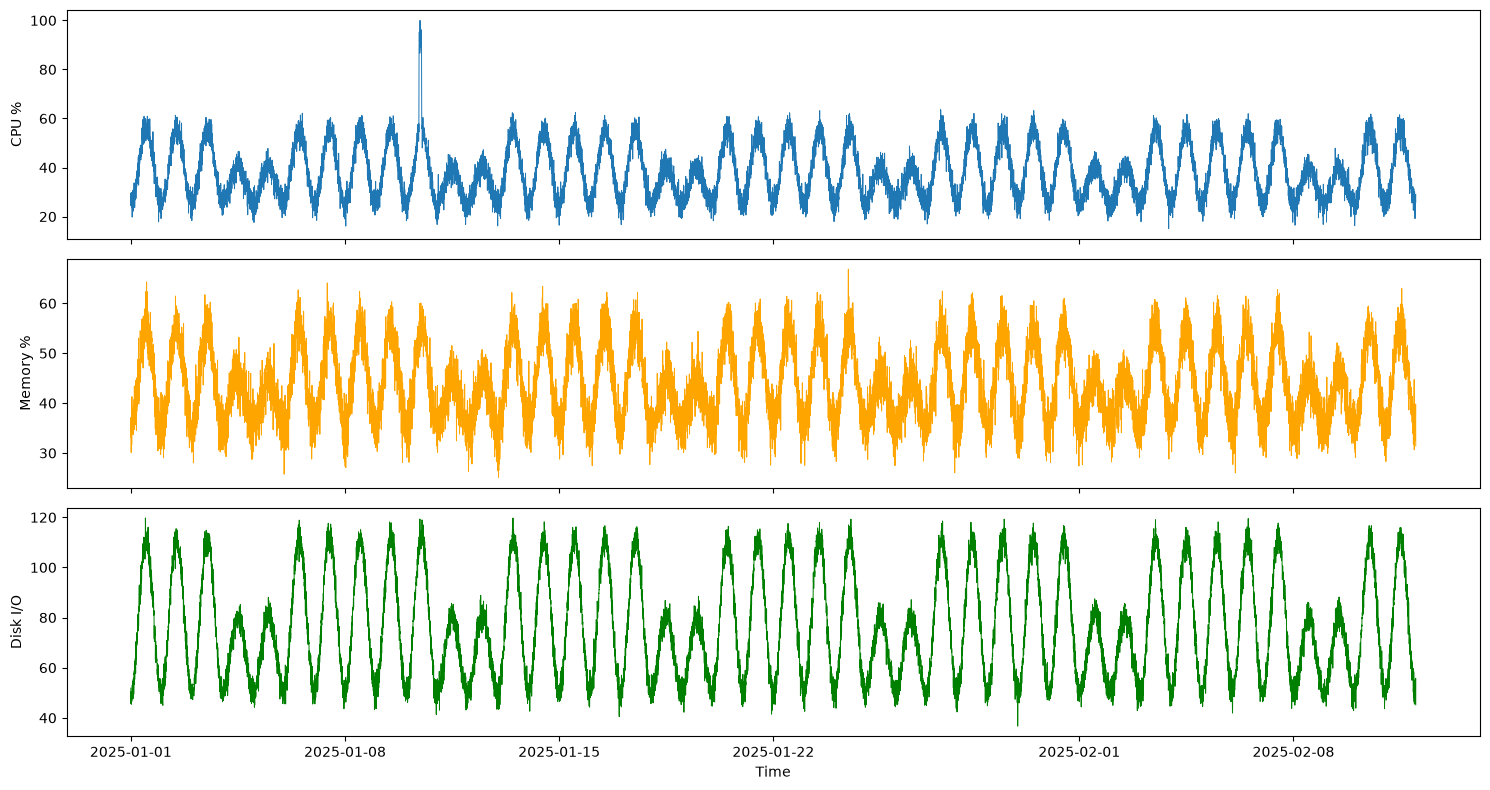

In [11]:
server = df[df['server_id'] == 'web_1']

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

axes[0].plot(server['timestamp'], server['cpu_percent'], linewidth=0.7)
axes[0].set_ylabel('CPU %')

axes[1].plot(server['timestamp'], server['memory_percent'], linewidth=0.7, color='orange')
axes[1].set_ylabel('Memory %')

axes[2].plot(server['timestamp'], server['disk_io'], linewidth=0.7, color='green')
axes[2].set_ylabel('Disk I/O')
axes[2].set_xlabel('Time')

plt.tight_layout()
plt.show()

## Feature engineering
For XGBoost features are needed to give more context to the model, the model wouldn't undertand for example 50 → 55 → 60 → 65 → 70 is a trend over time leading to an anomaly.

Below I have outlined features that could be created for the model to gain better context, I will engineer and train with a few features at a time instead of training using all the features.

Features:
- `time features`
- `Lag`
- `Rolling windows`
- `Trend features`
- `Residual and baseline`

Useful resource: https://medium.com/data-science-at-microsoft/introduction-to-feature-engineering-for-time-series-forecasting-620aa55fcab0

### Time features

- Hour (0-24)
- Day (0-6)

In [12]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek

df.head(10)

,timestamp,server_id,server_type,cpu_percent,memory_percent,disk_io,is_anomaly,is_predictive_anomaly,anomaly_type,hour,day_of_week
0,2025-01-01 00:00:00,web_1,web,24.585207,33.194309,51.865857,0,0,normal,0,2
1,2025-01-01 00:05:00,web_1,web,26.946724,37.129782,48.890155,0,0,normal,0,2
2,2025-01-01 00:10:00,web_1,web,29.583721,35.496424,45.627445,0,0,normal,0,2
3,2025-01-01 00:15:00,web_1,web,24.330454,30.116072,50.508945,0,0,normal,0,2
4,2025-01-01 00:20:00,web_1,web,24.356086,32.283149,47.617581,0,0,normal,0,2
5,2025-01-01 00:25:00,web_1,web,29.829008,34.611279,45.449479,0,0,normal,0,2
6,2025-01-01 00:30:00,web_1,web,27.433818,38.424553,47.917807,0,0,normal,0,2
7,2025-01-01 00:35:00,web_1,web,23.770490,36.510445,47.274504,0,0,normal,0,2
8,2025-01-01 00:40:00,web_1,web,26.861223,31.653193,48.527026,0,0,normal,0,2
9,2025-01-01 00:45:00,web_1,web,23.905126,34.775971,46.613106,0,0,normal,0,2


### Lag features
Lag features for each metric are computed at different timescales: 5 minutes, 15 minutes, 30 minutes, 60 minutes.

In [21]:
def create_lag_features(df, metric):
    # shift(1) - 5mins
    # shift(3) - 15mins
    # shift(6) - 30mins
    # shift(12) - 60mins
    shifts = [1,3,6,12]

    for shift in shifts:
        col_name = f'{metric}_lag_{shift*5}m'
        df[col_name] = df.groupby("server_id")[metric].shift(shift)
    return df

df = create_lag_features(df, "cpu_percent")
df = create_lag_features(df, "memory_percent")
df = create_lag_features(df, "disk_io")

In [22]:
df.head(20)

,timestamp,server_id,server_type,cpu_percent,memory_percent,disk_io,is_anomaly,is_predictive_anomaly,anomaly_type,hour,...,cpu_percent_lag_30m,cpu_percent_lag_60m,memory_percent_lag_5m,memory_percent_lag_15m,memory_percent_lag_30m,memory_percent_lag_60m,disk_io_lag_5m,disk_io_lag_15m,disk_io_lag_30m,disk_io_lag_60m
0,2025-01-01 00:00:00,web_1,web,24.585207,33.194309,51.865857,0,0,normal,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 00:05:00,web_1,web,26.946724,37.129782,48.890155,0,0,normal,0,...,NaN,NaN,33.194309,NaN,NaN,NaN,51.865857,NaN,NaN,NaN
2,2025-01-01 00:10:00,web_1,web,29.583721,35.496424,45.627445,0,0,normal,0,...,NaN,NaN,37.129782,NaN,NaN,NaN,48.890155,NaN,NaN,NaN
3,2025-01-01 00:15:00,web_1,web,24.330454,30.116072,50.508945,0,0,normal,0,...,NaN,NaN,35.496424,33.194309,NaN,NaN,45.627445,51.865857,NaN,NaN
4,2025-01-01 00:20:00,web_1,web,24.356086,32.283149,47.617581,0,0,normal,0,...,NaN,NaN,30.116072,37.129782,NaN,NaN,50.508945,48.890155,NaN,NaN
5,2025-01-01 00:25:00,web_1,web,29.829008,34.611279,45.449479,0,0,normal,0,...,NaN,NaN,32.283149,35.496424,NaN,NaN,47.617581,45.627445,NaN,NaN
6,2025-01-01 00:30:00,web_1,web,27.433818,38.424553,47.917807,0,0,normal,0,...,24.585207,NaN,34.611279,30.116072,33.194309,NaN,45.449479,50.508945,51.865857,NaN
7,2025-01-01 00:35:00,web_1,web,23.770490,36.510445,47.274504,0,0,normal,0,...,26.946724,NaN,38.424553,32.283149,37.129782,NaN,47.917807,47.617581,48.890155,NaN
8,2025-01-01 00:40:00,web_1,web,26.861223,31.653193,48.527026,0,0,normal,0,...,29.583721,NaN,36.510445,34.611279,35.496424,NaN,47.274504,45.449479,45.627445,NaN
9,2025-01-01 00:45:00,web_1,web,23.905126,34.775971,46.613106,0,0,normal,0,...,24.330454,NaN,31.653193,38.424553,30.116072,NaN,48.527026,47.917807,50.508945,NaN


## Target feature
The model will predict if an anomaly will occur in the next **30** mins, to support this a target feature needs to be created. This feature will be for all metrics so only one feature is needed `target_30m`

In [36]:
def target_feature(df):
    col_name='target_30m'

    future_values = []
    
    for shift in range(1,7):
        is_anomaly = df.groupby("server_id")["is_anomaly"].shift(-shift) == 1
        future_values.append(is_anomaly)

    future_values = pd.DataFrame(future_values).T

    df[col_name] = future_values.any(axis=1).astype(int)

    return df
    
df = target_feature(df)

df.head()

,timestamp,server_id,server_type,cpu_percent,memory_percent,disk_io,is_anomaly,is_predictive_anomaly,anomaly_type,hour,...,cpu_percent_lag_60m,memory_percent_lag_5m,memory_percent_lag_15m,memory_percent_lag_30m,memory_percent_lag_60m,disk_io_lag_5m,disk_io_lag_15m,disk_io_lag_30m,disk_io_lag_60m,target_30m
12,2025-01-01 01:00:00,web_1,web,19.783966,34.367228,52.174455,0,0,normal,1,...,24.585207,35.627367,34.775971,38.424553,33.194309,48.741343,46.613106,47.917807,51.865857,0
13,2025-01-01 01:05:00,web_1,web,20.439382,36.884642,53.008887,0,0,normal,1,...,26.946724,34.367228,41.296346,36.510445,37.129782,52.174455,49.543361,47.274504,48.890155,0
14,2025-01-01 01:10:00,web_1,web,24.024625,37.764504,52.203421,0,0,normal,1,...,29.583721,36.884642,35.627367,31.653193,35.496424,53.008887,48.741343,48.527026,45.627445,0
15,2025-01-01 01:15:00,web_1,web,22.777325,34.175374,50.925304,0,0,normal,1,...,24.330454,37.764504,34.367228,34.775971,30.116072,52.203421,52.174455,46.613106,50.508945,0
16,2025-01-01 01:20:00,web_1,web,26.869819,37.125776,51.066872,0,0,normal,1,...,24.356086,34.175374,36.884642,41.296346,32.283149,50.925304,53.008887,49.543361,47.617581,0


In [39]:
df[
    (df["server_id"] == "web_2") &
    (df["timestamp"].between("2025-01-16 15:00", "2025-01-16 16:35"))
][[
    "timestamp",
    "is_anomaly",
    "is_predictive_anomaly",
    "target_30m"
]]

,timestamp,is_anomaly,is_predictive_anomaly,target_30m
16596,2025-01-16 15:00:00,0,0,0
16597,2025-01-16 15:05:00,0,0,0
16598,2025-01-16 15:10:00,0,0,0
16599,2025-01-16 15:15:00,0,1,0
16600,2025-01-16 15:20:00,0,1,0
16601,2025-01-16 15:25:00,0,1,0
16602,2025-01-16 15:30:00,0,1,1
16603,2025-01-16 15:35:00,0,1,1
16604,2025-01-16 15:40:00,0,1,1
16605,2025-01-16 15:45:00,0,1,1


### Remove NaN

In [25]:
df = df.dropna()
df.head()

,timestamp,server_id,server_type,cpu_percent,memory_percent,disk_io,is_anomaly,is_predictive_anomaly,anomaly_type,hour,...,cpu_percent_lag_30m,cpu_percent_lag_60m,memory_percent_lag_5m,memory_percent_lag_15m,memory_percent_lag_30m,memory_percent_lag_60m,disk_io_lag_5m,disk_io_lag_15m,disk_io_lag_30m,disk_io_lag_60m
12,2025-01-01 01:00:00,web_1,web,19.783966,34.367228,52.174455,0,0,normal,1,...,27.433818,24.585207,35.627367,34.775971,38.424553,33.194309,48.741343,46.613106,47.917807,51.865857
13,2025-01-01 01:05:00,web_1,web,20.439382,36.884642,53.008887,0,0,normal,1,...,23.770490,26.946724,34.367228,41.296346,36.510445,37.129782,52.174455,49.543361,47.274504,48.890155
14,2025-01-01 01:10:00,web_1,web,24.024625,37.764504,52.203421,0,0,normal,1,...,26.861223,29.583721,36.884642,35.627367,31.653193,35.496424,53.008887,48.741343,48.527026,45.627445
15,2025-01-01 01:15:00,web_1,web,22.777325,34.175374,50.925304,0,0,normal,1,...,23.905126,24.330454,37.764504,34.367228,34.775971,30.116072,52.203421,52.174455,46.613106,50.508945
16,2025-01-01 01:20:00,web_1,web,26.869819,37.125776,51.066872,0,0,normal,1,...,23.967201,24.356086,34.175374,36.884642,41.296346,32.283149,50.925304,53.008887,49.543361,47.617581


In [26]:
df.to_csv('../data/lag_feature_dataset.csv', index=False)